**Suppose you are working in a data-driven job role, and you have to answer all these questions.**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pytrends.request import TrendReq

1. Write code that lets you easily search for different keywords.

In [2]:
# Setting up pytrend library
pytrend = TrendReq(hl="en-US", tz=360)
keyword = "data scientist"

In [3]:
# Data request
pytrend.build_payload([keyword], cat=0, timeframe='today 12-m', geo='', gprop='')

In [4]:
region_data = pytrend.interest_by_region()
sorted_region_data = region_data.sort_values(by=keyword, ascending=False)
sorted_region_data.head(10)

,data scientist
geoName,
Singapore,100
St. Helena,99
India,94
United States,70
Tunisia,65
South Africa,63
Nepal,62
Sri Lanka,61
United Kingdom,55


2. Find and plot graph of the top 10 countries searching for those keywords.

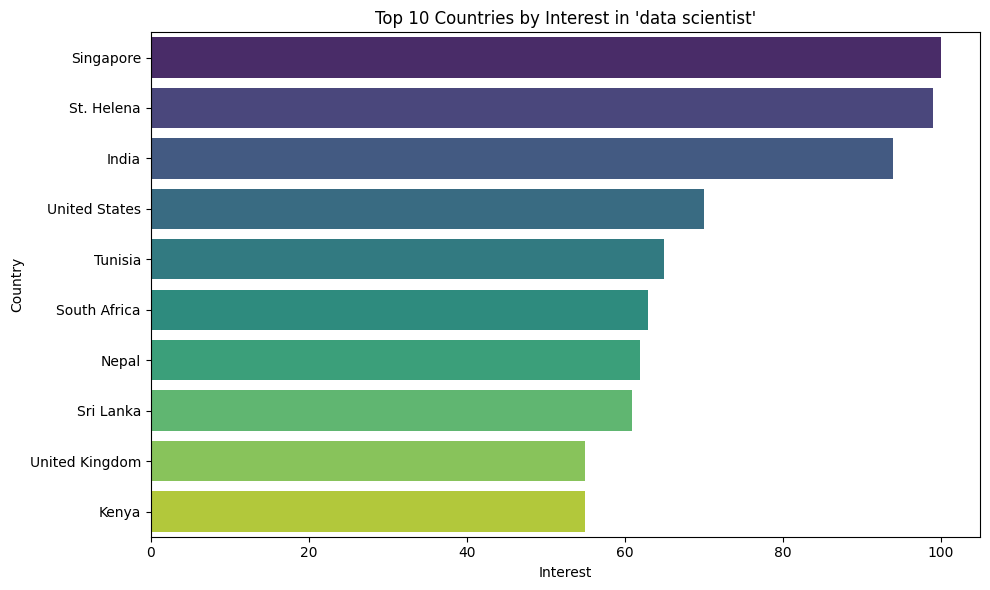

In [5]:
top_10_data = region_data.sort_values(by=keyword, ascending=False).head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=top_10_data[keyword],
    y=top_10_data.index,
    hue=top_10_data.index,
    palette="viridis",
    legend=False
)

plt.title(f"Top 10 Countries by Interest in '{keyword}'")
plt.xlabel("Interest")
plt.ylabel("Country")

plt.tight_layout()

plt.show()

3. Make a world map showing where the keyword is searched most.

In [6]:
region_data = region_data.reset_index()

fig = px.choropleth(
    region_data,
    locations='geoName',
    locationmode='country names',
    color=keyword,
    hover_name='geoName',
    title=f"Global Search Interest for '{keyword}'",
    color_continuous_scale='Blues',
    labels={keyword: 'Interest Score'}
)

fig.show()

4. Show how the search interest changed over the years.

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



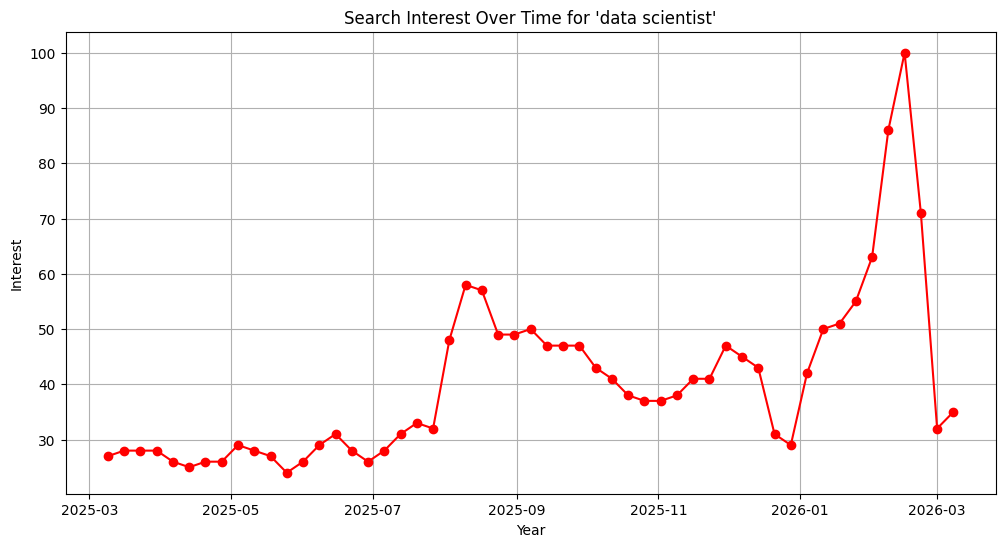

In [7]:
year_data = pytrend.interest_over_time()
plt.figure(figsize=(12, 6))
plt.plot(year_data.index, year_data[keyword], marker='o', linestyle='-', color='red')
plt.title(f"Search Interest Over Time for '{keyword}'")
plt.xlabel("Year")
plt.ylabel("Interest")
plt.grid(True)
plt.show()

5. Compare similar keywords on a graph.

/usr/local/lib/python3.12/dist-packages/pytrends/request.py:260: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



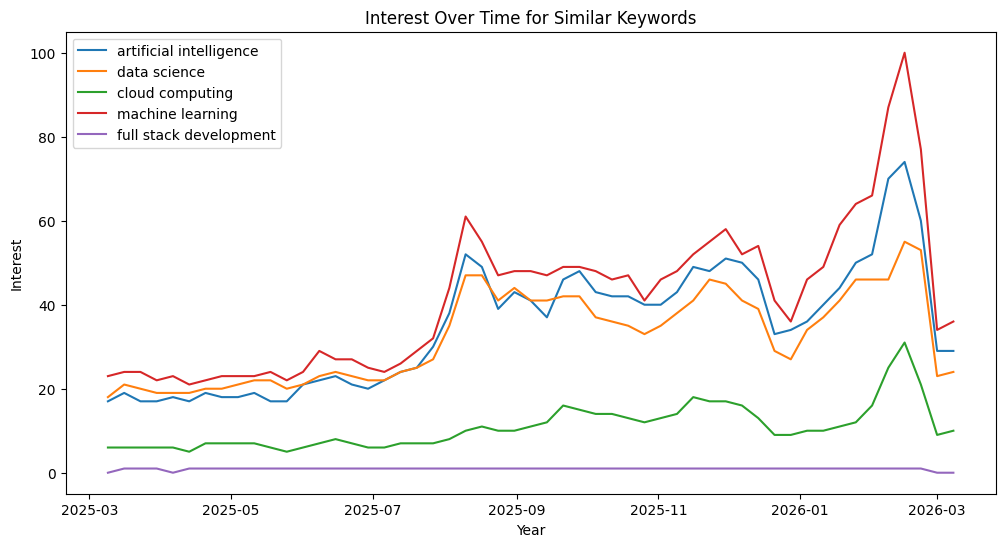

In [9]:
trending_search = ["artificial intelligence", "data science", "cloud computing", "machine learning", "full stack development"]
pytrend.build_payload(trending_search, cat=0, timeframe='today 12-m', geo='', gprop='')
trend_compare = pytrend.interest_over_time()
plt.figure(figsize=(12, 6))
for keyword in trending_search:
    plt.plot(trend_compare.index, trend_compare[keyword], label=keyword)
plt.title("Interest Over Time for Similar Keywords")
plt.xlabel("Year")
plt.ylabel("Interest")
plt.legend()